In [3]:
# ============================================================
# LIBRARIAT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Lexo dataset-in e pastruar
df = pd.read_csv("../data/processed/laliga_master.csv")
df_elo = pd.read_csv("../data/processed/laliga_elo.csv")

# Bashko Elo me dataset-in kryesor
df = df.merge(df_elo, on=["Squad", "sezoni"], how="left")

print("Dimensionet:", df.shape)
print("OK!")

Dimensionet: (420, 34)
OK!


In [6]:
# ============================================================
# KONTROLLO KOLONAT
# ============================================================
print("Kolonat në df_pca:")
print(df_pca.columns.tolist())
print()
print("Tipet:")
print(df_pca.dtypes)

Kolonat në df_pca:
['Squad', 'sezoni', 'Pts', 'GF', 'GA', 'GD', 'Sh', 'SoT', 'Save%', 'Poss', 'Age', 'CrdY', 'elo']

Tipet:
Squad         str
sezoni        str
Pts         int64
GF          int64
GA          int64
GD          int64
Sh        float64
SoT       float64
Save%     float64
Poss      float64
Age       float64
CrdY      float64
elo       float64
dtype: object


In [7]:
# ============================================================
# APLIKO PCA
# ============================================================

# Hapi 1 — Merr vetem vlerat numerike
X = df_pca[kolonat_pca].values

# Hapi 2 — Standardizo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Hapi 3 — Apliko PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianca e shpjeguar nga çdo komponent
varianca = pca.explained_variance_ratio_

print("=== VARIANCA E SHPJEGUAR PER KOMPONENT ===")
for i, v in enumerate(varianca):
    print(f"PC{i+1:2}: {v*100:6.2f}%  "
          f"(Kumulative: {varianca[:i+1].sum()*100:.2f}%)")

=== VARIANCA E SHPJEGUAR PER KOMPONENT ===
PC 1:  60.21%  (Kumulative: 60.21%)
PC 2:  13.60%  (Kumulative: 73.81%)
PC 3:   9.13%  (Kumulative: 82.93%)
PC 4:   7.12%  (Kumulative: 90.06%)
PC 5:   3.30%  (Kumulative: 93.35%)
PC 6:   2.73%  (Kumulative: 96.09%)
PC 7:   1.97%  (Kumulative: 98.05%)
PC 8:   1.03%  (Kumulative: 99.08%)
PC 9:   0.55%  (Kumulative: 99.63%)
PC10:   0.37%  (Kumulative: 100.00%)
PC11:   0.00%  (Kumulative: 100.00%)


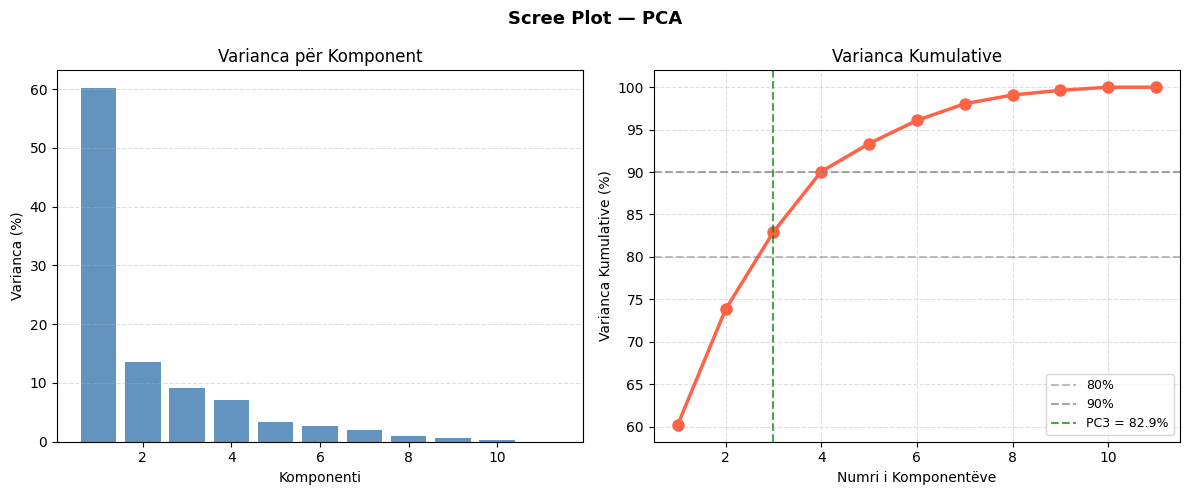

Grafiku u ruajt!


In [8]:
# ============================================================
# SCREE PLOT — Vizualizimi i Variancës
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Varianca per komponent ---
ax1.bar(range(1, len(varianca)+1), varianca*100, 
        color="steelblue", alpha=0.85)
ax1.set_xlabel("Komponenti")
ax1.set_ylabel("Varianca (%)")
ax1.set_title("Varianca për Komponent")
ax1.grid(axis="y", linestyle="--", alpha=0.4)

# --- Varianca kumulative ---
ax2.plot(range(1, len(varianca)+1), 
         varianca.cumsum()*100,
         color="tomato", linewidth=2.5, marker="o", markersize=8)
ax2.axhline(y=80, color="gray", linestyle="--", alpha=0.5, label="80%")
ax2.axhline(y=90, color="gray", linestyle="--", alpha=0.7, label="90%")
ax2.axvline(x=3,  color="green", linestyle="--", alpha=0.7, label="PC3 = 82.9%")
ax2.set_xlabel("Numri i Komponentëve")
ax2.set_ylabel("Varianca Kumulative (%)")
ax2.set_title("Varianca Kumulative")
ax2.legend(fontsize=9)
ax2.grid(linestyle="--", alpha=0.4)

plt.suptitle("Scree Plot — PCA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/16_scree_plot.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

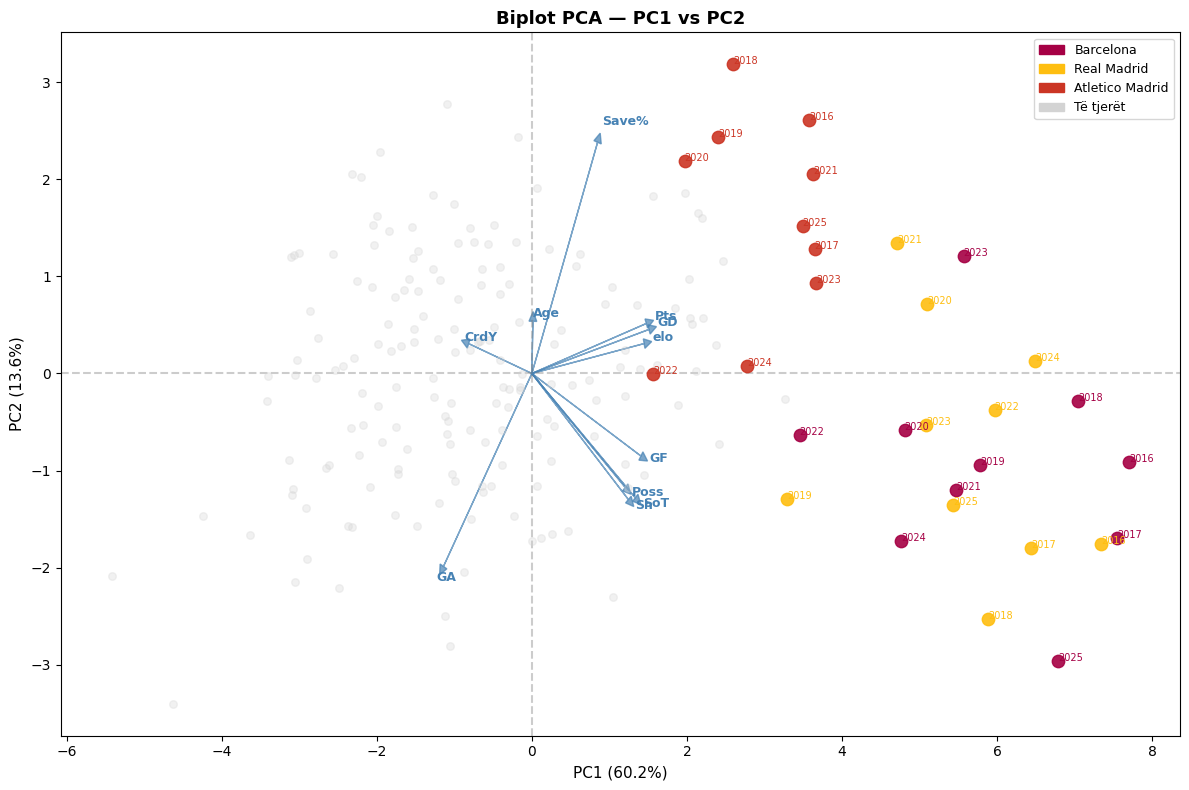

Grafiku u ruajt!


In [9]:
# ============================================================
# BIPLOT — PC1 vs PC2
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

# Ngjyra per ekipet kryesore
ngjyrat_ekip = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524"
}

# Vizato pikat per cdo ekip/sezon
for _, row in df_pca.iterrows():
    idx = df_pca.index.get_loc(_)
    ngjyra = ngjyrat_ekip.get(row["Squad"], "lightgray")
    alpha  = 0.9 if row["Squad"] in ngjyrat_ekip else 0.3
    size   = 80  if row["Squad"] in ngjyrat_ekip else 30

    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               color=ngjyra, alpha=alpha, s=size, zorder=3)

# Shto emrat per ekipet kryesore
for ekip in ngjyrat_ekip:
    df_ekip_idx = df_pca[df_pca["Squad"] == ekip].index
    for idx in df_ekip_idx:
        pos = df_pca.index.get_loc(idx)
        ax.annotate(df_pca.loc[idx, "sezoni"][-4:],
                    (X_pca[pos, 0], X_pca[pos, 1]),
                    fontsize=7, color=ngjyrat_ekip[ekip])

# Vizato vektoret e variablave (loadings)
loadings = pca.components_.T
for i, kolona in enumerate(kolonat_pca):
    ax.arrow(0, 0, loadings[i, 0]*4, loadings[i, 1]*4,
             head_width=0.1, head_length=0.1,
             fc="steelblue", ec="steelblue", alpha=0.7)
    ax.text(loadings[i, 0]*4.3, loadings[i, 1]*4.3,
            kolona, fontsize=9, color="steelblue", fontweight="bold")

ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.4)
ax.set_xlabel(f"PC1 ({varianca[0]*100:.1f}%)", fontsize=11)
ax.set_ylabel(f"PC2 ({varianca[1]*100:.1f}%)", fontsize=11)
ax.set_title("Biplot PCA — PC1 vs PC2", fontsize=13, fontweight="bold")

# Legjenda
from matplotlib.patches import Patch
legjenda = [Patch(color="#A50044", label="Barcelona"),
            Patch(color="#FEBE10", label="Real Madrid"),
            Patch(color="#CB3524", label="Atletico Madrid"),
            Patch(color="lightgray", label="Të tjerët")]
ax.legend(handles=legjenda, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/17_biplot.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

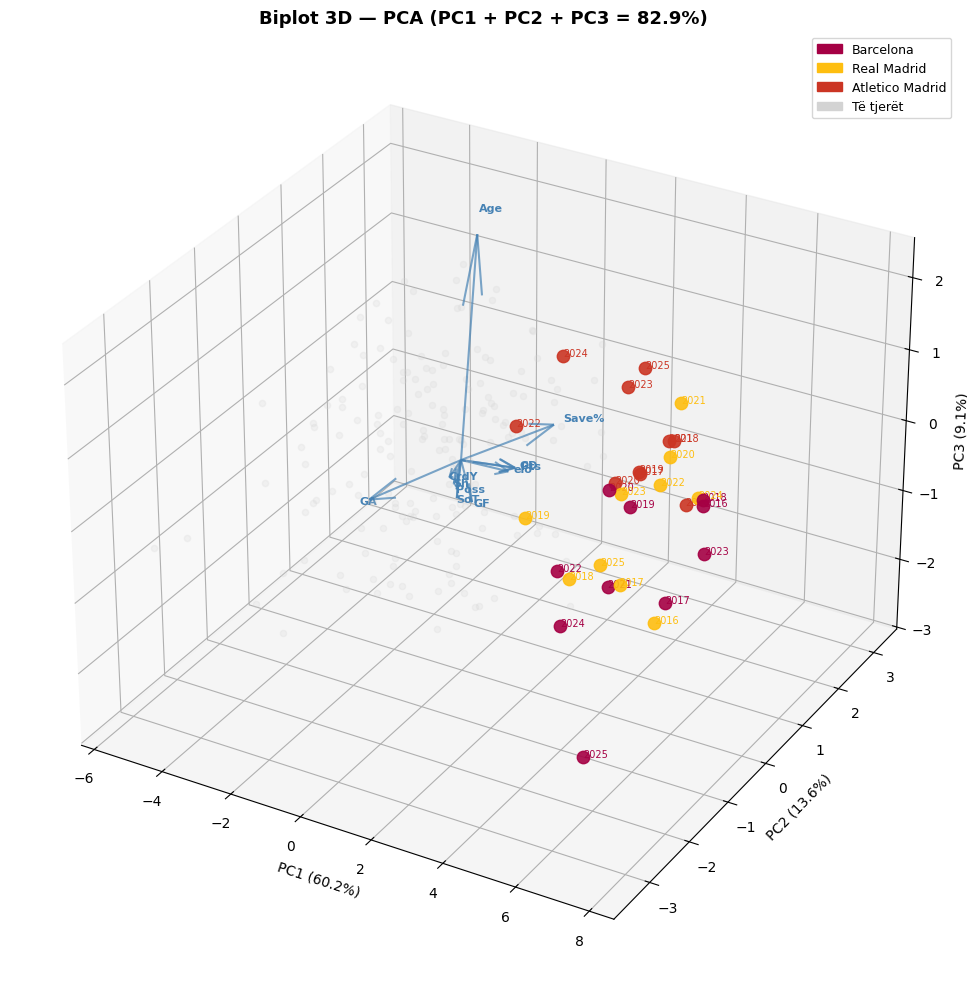

Grafiku u ruajt!


In [10]:
# ============================================================
# BIPLOT 3D — PC1 vs PC2 vs PC3
# ============================================================
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(14, 10))
ax  = fig.add_subplot(111, projection="3d")

ngjyrat_ekip = {
    "Barcelona"      : "#A50044",
    "Real Madrid"    : "#FEBE10",
    "Atletico Madrid": "#CB3524"
}

# Vizato pikat
for _, row in df_pca.iterrows():
    idx    = df_pca.index.get_loc(_)
    ngjyra = ngjyrat_ekip.get(row["Squad"], "lightgray")
    alpha  = 0.9 if row["Squad"] in ngjyrat_ekip else 0.2
    size   = 80  if row["Squad"] in ngjyrat_ekip else 20

    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
               color=ngjyra, alpha=alpha, s=size, zorder=3)

    # Etiketat vetem per ekipet kryesore
    if row["Squad"] in ngjyrat_ekip:
        ax.text(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2],
                row["sezoni"][-4:], fontsize=7,
                color=ngjyrat_ekip[row["Squad"]])

# Vizato vektoret e variablave
loadings = pca.components_.T
for i, kolona in enumerate(kolonat_pca):
    ax.quiver(0, 0, 0,
              loadings[i, 0]*3,
              loadings[i, 1]*3,
              loadings[i, 2]*3,
              color="steelblue", alpha=0.7, linewidth=1.5)
    ax.text(loadings[i, 0]*3.3,
            loadings[i, 1]*3.3,
            loadings[i, 2]*3.3,
            kolona, fontsize=8, color="steelblue", fontweight="bold")

ax.set_xlabel(f"PC1 ({varianca[0]*100:.1f}%)", fontsize=10)
ax.set_ylabel(f"PC2 ({varianca[1]*100:.1f}%)", fontsize=10)
ax.set_zlabel(f"PC3 ({varianca[2]*100:.1f}%)", fontsize=10)
ax.set_title("Biplot 3D — PCA (PC1 + PC2 + PC3 = 82.9%)",
             fontsize=13, fontweight="bold")

# Legjenda
from matplotlib.patches import Patch
legjenda = [Patch(color="#A50044", label="Barcelona"),
            Patch(color="#FEBE10", label="Real Madrid"),
            Patch(color="#CB3524", label="Atletico Madrid"),
            Patch(color="lightgray", label="Të tjerët")]
ax.legend(handles=legjenda, fontsize=9)

plt.tight_layout()
plt.savefig("../outputs/figures/17_biplot_3d.png", dpi=150, bbox_inches="tight")
plt.show()

print("Grafiku u ruajt!")

In [11]:
# ============================================================
# LOADINGS — ÇFARË PËRFAQËSON ÇDO PC
# ============================================================

df_loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=kolonat_pca,
    columns=["PC1", "PC2", "PC3"]
).round(3)

print("=== LOADINGS — KONTRIBUTI I ÇDO VARIABLE ===")
print(df_loadings)
print()

# Variabli me ndikim me te madh per cdo PC
print("=== VARIABLI DOMINANT PER ÇDO PC ===")
for pc in ["PC1", "PC2", "PC3"]:
    dominant = df_loadings[pc].abs().idxmax()
    vlera    = df_loadings.loc[dominant, pc]
    print(f"{pc}: {dominant:10} ({vlera:+.3f})")

=== LOADINGS — KONTRIBUTI I ÇDO VARIABLE ===
         PC1    PC2    PC3
Pts    0.369  0.129 -0.048
GF     0.352 -0.213 -0.043
GA    -0.285 -0.497  0.018
GD     0.378  0.113 -0.038
Sh     0.311 -0.325  0.092
SoT    0.333 -0.320  0.026
Save%  0.212  0.595 -0.090
Poss   0.301 -0.293  0.049
Age    0.003  0.134  0.975
CrdY  -0.204  0.077 -0.149
elo    0.362  0.077 -0.040

=== VARIABLI DOMINANT PER ÇDO PC ===
PC1: GD         (+0.378)
PC2: Save%      (+0.595)
PC3: Age        (+0.975)


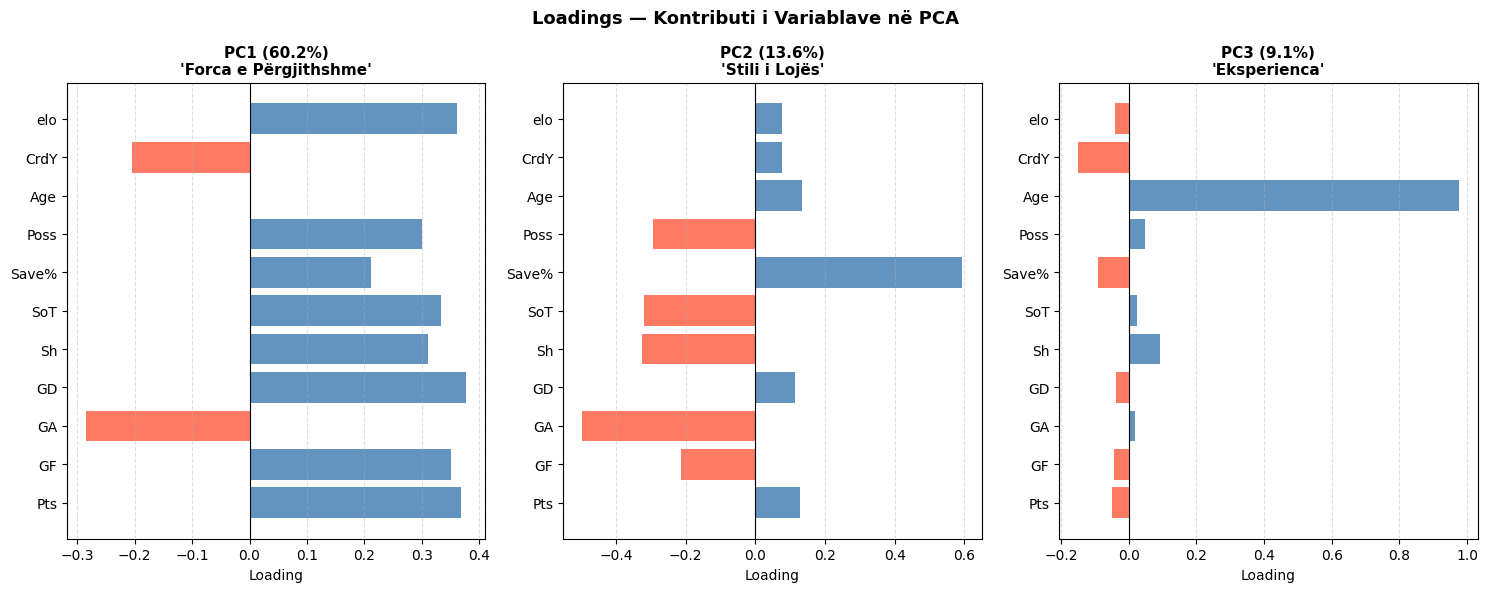

Grafiku u ruajt!


In [12]:
# ============================================================
# VIZUALIZIMI I LOADINGS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, (ax, pc) in enumerate(zip(axes, ["PC1", "PC2", "PC3"])):
    ngjyrat = ["tomato" if v < 0 else "steelblue" 
               for v in df_loadings[pc]]
    
    bars = ax.barh(df_loadings.index, df_loadings[pc], 
                   color=ngjyrat, alpha=0.85)
    
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_title(f"{pc} ({varianca[i]*100:.1f}%)\n"
                 f"'{['Forca e Përgjithshme', 'Stili i Lojës', 'Eksperienca'][i]}'",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Loading")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.suptitle("Loadings — Kontributi i Variablave në PCA",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/18_loadings.png", dpi=150)
plt.show()

print("Grafiku u ruajt!")

In [13]:
# Eksporto komponentet PCA
df_pca_rezultat = df_pca[["Squad", "sezoni"]].copy()
df_pca_rezultat["PC1"] = X_pca[:, 0]
df_pca_rezultat["PC2"] = X_pca[:, 1]
df_pca_rezultat["PC3"] = X_pca[:, 2]

df_pca_rezultat.to_csv("../data/processed/laliga_pca.csv", index=False)
print("U eksportua!")

U eksportua!
